# Causal Inference Basics

This notebook demonstrates basic causal inference methods available in the datascienceutils library.

## Methods Covered:
- **Average Treatment Effect (ATE)** - Regression-based estimation
- **Propensity Score Matching (PSM)** - Matching treated/control units
- **Instrumental Variables (IV)** - Two-stage least squares
- **Difference-in-Differences (DiD)** - Panel data analysis

## Prerequisites
```bash
maturin develop --release
pip install jupyter matplotlib numpy
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datascienceutils as dsu

np.random.seed(42)
print(f"Using datascienceutils v{dsu.__version__}")

Using datascienceutils v0.1.0


## 1. Average Treatment Effect (ATE)

ATE estimates the average effect of a treatment across all units.

**Scenario**: Estimating the effect of a training program on employee productivity.

In [2]:
# Generate synthetic data
n = 500

# Confounders: age and experience
confounders = np.random.randn(n, 2)
confounders[:, 0] = confounders[:, 0] * 10 + 35  # Age: mean=35, std=10
confounders[:, 1] = confounders[:, 1] * 5 + 8    # Experience: mean=8, std=5

# Treatment assignment (influenced by confounders)
treatment_prob = 1 / (1 + np.exp(-(confounders[:, 0] - 35) / 10 - (confounders[:, 1] - 8) / 5))
treatment = (np.random.rand(n) < treatment_prob).astype(float)

# True treatment effect = 10 units
true_effect = 10.0

# Outcome: productivity (influenced by confounders and treatment)
outcome = (
    50 +  # Baseline
    0.5 * confounders[:, 0] +  # Age effect
    1.0 * confounders[:, 1] +  # Experience effect
    true_effect * treatment +  # Treatment effect
    np.random.randn(n) * 5     # Noise
)

print(f"Sample size: {n}")
print(f"Treated units: {int(treatment.sum())} ({100*treatment.mean():.1f}%)")
print(f"Control units: {int((1-treatment).sum())} ({100*(1-treatment.mean()):.1f}%)")
print(f"\nTrue treatment effect: {true_effect:.2f}")

Sample size: 500
Treated units: 259 (51.8%)
Control units: 241 (48.2%)

True treatment effect: 10.00


In [3]:
# Estimate ATE
ate = dsu.estimate_ate(confounders, treatment, outcome)

print(f"Estimated ATE: {ate:.2f}")
print(f"True effect: {true_effect:.2f}")
print(f"Estimation error: {abs(ate - true_effect):.2f}")

AttributeError: module 'datascienceutils' has no attribute 'estimate_ate'

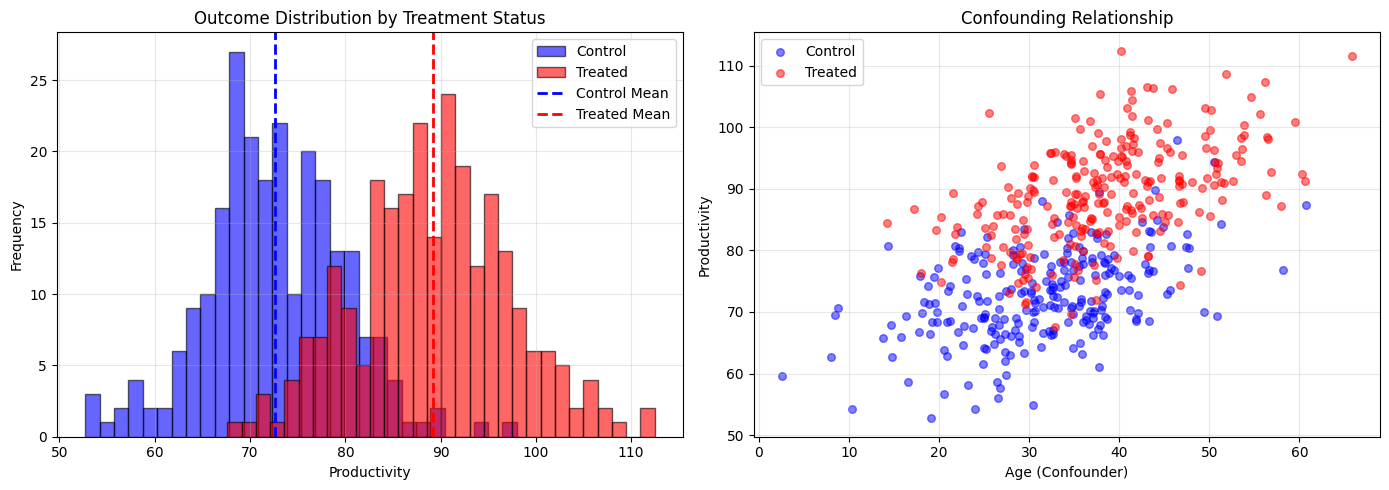


Naive estimate (ignoring confounders): 16.57


NameError: name 'ate' is not defined

In [4]:
# Visualize treatment effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of outcomes by treatment
axes[0].hist(outcome[treatment == 0], bins=30, alpha=0.6, label='Control', color='blue', edgecolor='black')
axes[0].hist(outcome[treatment == 1], bins=30, alpha=0.6, label='Treated', color='red', edgecolor='black')
axes[0].axvline(outcome[treatment == 0].mean(), color='blue', linestyle='--', linewidth=2, label='Control Mean')
axes[0].axvline(outcome[treatment == 1].mean(), color='red', linestyle='--', linewidth=2, label='Treated Mean')
axes[0].set_xlabel('Productivity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Outcome Distribution by Treatment Status')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot: confounders vs outcome
scatter_control = axes[1].scatter(confounders[treatment == 0, 0], outcome[treatment == 0], 
                                   alpha=0.5, s=30, label='Control', color='blue')
scatter_treated = axes[1].scatter(confounders[treatment == 1, 0], outcome[treatment == 1], 
                                   alpha=0.5, s=30, label='Treated', color='red')
axes[1].set_xlabel('Age (Confounder)')
axes[1].set_ylabel('Productivity')
axes[1].set_title('Confounding Relationship')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNaive estimate (ignoring confounders): {outcome[treatment == 1].mean() - outcome[treatment == 0].mean():.2f}")
print(f"ATE estimate (adjusting for confounders): {ate:.2f}")

## 2. Propensity Score Matching (PSM)

PSM matches treated and control units based on their probability of receiving treatment.

**Scenario**: Evaluating the effect of a marketing campaign on sales.

In [5]:
# Generate synthetic data for PSM
n = 400

# Confounders: customer age and previous purchases
confounders_psm = np.random.randn(n, 2)
confounders_psm[:, 0] = confounders_psm[:, 0] * 15 + 40  # Age
confounders_psm[:, 1] = np.abs(confounders_psm[:, 1]) * 3 + 2  # Previous purchases

# Treatment: received marketing email
treatment_prob_psm = 1 / (1 + np.exp(-0.05 * (confounders_psm[:, 0] - 40) - 0.2 * confounders_psm[:, 1]))
treatment_psm = (np.random.rand(n) < treatment_prob_psm).astype(float)

# True effect = 25 dollars
true_effect_psm = 25.0

# Outcome: sales amount
outcome_psm = (
    100 +  # Baseline
    1.5 * confounders_psm[:, 0] +  # Age effect
    10.0 * confounders_psm[:, 1] +  # Previous purchases effect
    true_effect_psm * treatment_psm +  # Treatment effect
    np.random.randn(n) * 15  # Noise
)

print(f"Sample size: {n}")
print(f"Treated: {int(treatment_psm.sum())}")
print(f"Control: {int((1-treatment_psm).sum())}")

Sample size: 400
Treated: 270
Control: 130


In [6]:
# Estimate using PSM
psm_ate = dsu.propensity_score_matching(confounders_psm, treatment_psm, outcome_psm)

print(f"PSM Estimated ATE: ${psm_ate:.2f}")
print(f"True effect: ${true_effect_psm:.2f}")
print(f"Estimation error: ${abs(psm_ate - true_effect_psm):.2f}")

AttributeError: module 'datascienceutils' has no attribute 'propensity_score_matching'

In [ ]:
# Visualize PSM results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
data_to_plot = [outcome_psm[treatment_psm == 0], outcome_psm[treatment_psm == 1]]
bp = axes[0].boxplot(data_to_plot, labels=['Control', 'Treated'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0].set_ylabel('Sales ($)')
axes[0].set_title('Sales Distribution by Treatment')
axes[0].grid(True, alpha=0.3)

# Effect comparison
methods = ['Naive\nDifference', 'PSM\nEstimate', 'True\nEffect']
naive_diff = outcome_psm[treatment_psm == 1].mean() - outcome_psm[treatment_psm == 0].mean()
effects = [naive_diff, psm_ate, true_effect_psm]
colors = ['gray', 'blue', 'green']

bars = axes[1].bar(methods, effects, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=true_effect_psm, color='green', linestyle='--', linewidth=2, label='True Effect')
axes[1].set_ylabel('Treatment Effect ($)')
axes[1].set_title('Method Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, effect in zip(bars, effects):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'${effect:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Instrumental Variables (IV)

IV estimation uses an instrument that affects treatment but not the outcome directly.

**Scenario**: Estimating the effect of education on income using distance to college as an instrument.

In [ ]:
# Generate synthetic data for IV
n = 600

# Instrument: distance to nearest college (in miles)
instrument = np.random.exponential(scale=20, size=n)

# Treatment: years of education (affected by distance)
treatment_iv = 12 - 0.1 * instrument + np.random.randn(n) * 2
treatment_iv = np.clip(treatment_iv, 8, 20)  # Realistic range

# True effect: $5000 per year of education
true_effect_iv = 5000.0

# Outcome: annual income (in thousands)
# Note: instrument doesn't directly affect outcome
outcome_iv = (
    20 +  # Baseline (in thousands)
    true_effect_iv * treatment_iv / 1000 +  # Education effect
    np.random.randn(n) * 10  # Noise
)

print(f"Sample size: {n}")
print(f"Mean education: {treatment_iv.mean():.2f} years")
print(f"Mean distance to college: {instrument.mean():.2f} miles")
print(f"Mean income: ${outcome_iv.mean():.2f}k")

In [ ]:
# Estimate using IV
iv_estimate = dsu.instrumental_variable(treatment_iv, outcome_iv, instrument)

print(f"IV Estimate: ${iv_estimate * 1000:.2f} per year of education")
print(f"True effect: ${true_effect_iv:.2f} per year")
print(f"Estimation error: ${abs(iv_estimate * 1000 - true_effect_iv):.2f}")

In [ ]:
# Visualize IV relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Instrument vs Treatment (First stage)
axes[0].scatter(instrument, treatment_iv, alpha=0.5, s=20)
z = np.polyfit(instrument, treatment_iv, 1)
p = np.poly1d(z)
axes[0].plot(instrument, p(instrument), "r--", linewidth=2, label=f'Fit: y={z[0]:.3f}x+{z[1]:.2f}')
axes[0].set_xlabel('Distance to College (miles)')
axes[0].set_ylabel('Years of Education')
axes[0].set_title('First Stage: Instrument → Treatment')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Treatment vs Outcome
axes[1].scatter(treatment_iv, outcome_iv, alpha=0.5, s=20)
z2 = np.polyfit(treatment_iv, outcome_iv, 1)
p2 = np.poly1d(z2)
axes[1].plot(treatment_iv, p2(treatment_iv), "r--", linewidth=2, label=f'Fit: y={z2[0]:.2f}x+{z2[1]:.2f}')
axes[1].set_xlabel('Years of Education')
axes[1].set_ylabel('Income ($k)')
axes[1].set_title('Treatment → Outcome')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Instrument vs Outcome (should be weak/indirect)
axes[2].scatter(instrument, outcome_iv, alpha=0.5, s=20, color='gray')
axes[2].set_xlabel('Distance to College (miles)')
axes[2].set_ylabel('Income ($k)')
axes[2].set_title('Instrument → Outcome (Indirect Only)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Difference-in-Differences (DiD)

DiD compares changes over time between treatment and control groups.

**Scenario**: Evaluating the impact of a minimum wage increase on employment.

In [7]:
# Generate synthetic DiD data
# Two groups: treated state (group=1) and control state (group=0)
# Two time periods: before (time=0) and after (time=1) policy change

n_per_cell = 50

# Group indicator
group = np.array([0]*n_per_cell*2 + [1]*n_per_cell*2)

# Time indicator
time = np.array([0]*n_per_cell + [1]*n_per_cell + [0]*n_per_cell + [1]*n_per_cell)

# True DiD effect = -5 (negative impact on employment)
true_did_effect = -5.0

# Outcome: employment rate
# Control group: 60 (pre) → 62 (post) [+2 trend]
# Treatment group: 60 (pre) → 57 (post) [+2 trend - 5 treatment effect = -3]
outcome_did = np.zeros(len(group))

# Control, Pre
outcome_did[:n_per_cell] = 60 + np.random.randn(n_per_cell) * 2

# Control, Post (trend = +2)
outcome_did[n_per_cell:n_per_cell*2] = 62 + np.random.randn(n_per_cell) * 2

# Treatment, Pre
outcome_did[n_per_cell*2:n_per_cell*3] = 60 + np.random.randn(n_per_cell) * 2

# Treatment, Post (trend = +2, treatment = -5)
outcome_did[n_per_cell*3:] = 57 + np.random.randn(n_per_cell) * 2

print(f"Total observations: {len(group)}")
print(f"Observations per cell: {n_per_cell}")
print(f"\nMean outcomes:")
print(f"  Control, Pre:  {outcome_did[(group==0) & (time==0)].mean():.2f}")
print(f"  Control, Post: {outcome_did[(group==0) & (time==1)].mean():.2f}")
print(f"  Treated, Pre:  {outcome_did[(group==1) & (time==0)].mean():.2f}")
print(f"  Treated, Post: {outcome_did[(group==1) & (time==1)].mean():.2f}")

Total observations: 200
Observations per cell: 50

Mean outcomes:
  Control, Pre:  60.13
  Control, Post: 61.85
  Treated, Pre:  60.18
  Treated, Post: 57.25


In [ ]:
# Estimate DiD
did_estimate = dsu.diff_in_diff(group, time, outcome_did)

print(f"DiD Estimate: {did_estimate:.2f}")
print(f"True effect: {true_did_effect:.2f}")
print(f"Estimation error: {abs(did_estimate - true_did_effect):.2f}")

In [ ]:
# Visualize DiD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calculate means for each group-time combination
control_pre = outcome_did[(group==0) & (time==0)].mean()
control_post = outcome_did[(group==0) & (time==1)].mean()
treated_pre = outcome_did[(group==1) & (time==0)].mean()
treated_post = outcome_did[(group==1) & (time==1)].mean()

# Line plot showing parallel trends
axes[0].plot([0, 1], [control_pre, control_post], 'o-', linewidth=2, markersize=10, 
             label='Control State', color='blue')
axes[0].plot([0, 1], [treated_pre, treated_post], 'o-', linewidth=2, markersize=10, 
             label='Treated State', color='red')

# Counterfactual (what would have happened without treatment)
counterfactual = treated_pre + (control_post - control_pre)
axes[0].plot([0, 1], [treated_pre, counterfactual], 'o--', linewidth=2, markersize=8, 
             label='Counterfactual', color='orange', alpha=0.7)

# Annotate the treatment effect
axes[0].annotate('', xy=(1.05, treated_post), xytext=(1.05, counterfactual),
                arrowprops=dict(arrowstyle='<->', color='green', lw=2))
axes[0].text(1.1, (treated_post + counterfactual)/2, f'DiD Effect\n{did_estimate:.1f}', 
            fontsize=10, color='green', fontweight='bold')

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Before Policy', 'After Policy'])
axes[0].set_ylabel('Employment Rate (%)')
axes[0].set_title('Difference-in-Differences Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-0.1, 1.3)

# Bar chart showing the decomposition
labels = ['Control\nChange', 'Treated\nChange', 'DiD\nEffect']
control_change = control_post - control_pre
treated_change = treated_post - treated_pre
values = [control_change, treated_change, did_estimate]
colors_bar = ['blue', 'red', 'green']

bars = axes[1].bar(labels, values, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Change in Employment Rate')
axes[1].set_title('DiD Decomposition')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.2f}', ha='center', va='bottom' if height > 0 else 'top', 
                fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  Control group trend: +{control_change:.2f}")
print(f"  Treated group change: {treated_change:.2f}")
print(f"  DiD effect (treatment impact): {did_estimate:.2f}")

## Summary

This notebook demonstrated four fundamental causal inference methods:

1. **ATE** - Simple regression-based estimation, requires controlling for confounders
2. **PSM** - Matches units with similar propensity scores, robust to confounding
3. **IV** - Uses instrumental variables to address endogeneity
4. **DiD** - Exploits panel structure to control for time-invariant confounders

### When to Use Each Method:

- **ATE**: When you have good measures of all confounders
- **PSM**: When treatment assignment is based on observables
- **IV**: When you have a valid instrument and suspect endogeneity
- **DiD**: When you have panel data and parallel trends assumption holds

### Next Steps:

- Explore advanced estimators (RDD, Synthetic Control, Mediation, CATE)
- Learn about causal graph construction and visualization
- Apply these methods to real-world datasets